# Scenario-Based Cyber Risk Analysis

This notebook compares financial risk across different cyber scenarios:

- Ransomware
- Cloud Data Breach
- AI Misuse

Goal:
Understand which scenarios drive the highest financial exposure and tail risk.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [8]:
scenarios = {
    "Ransomware": {"tef": (1, 3, 6), "mean": 14.5, "sigma": 0.7},
    "Cloud Breach": {"tef": (0.5, 1, 2), "mean": 15, "sigma": 0.6},
    "AI Misuse": {"tef": (2, 4, 8), "mean": 13.5, "sigma": 0.5},
}

In [9]:
results = {}

for scenario, params in scenarios.items():
    tef = np.random.triangular(*params["tef"], size=10000)
    loss = np.random.lognormal(mean=params["mean"], sigma=params["sigma"], size=10000)
    
    ale = tef * loss
    results[scenario] = ale

In [10]:
summary = {}

for scenario, ale in results.items():
    summary[scenario] = {
        "Median": np.percentile(ale, 50),
        "90th %": np.percentile(ale, 90),
        "95th %": np.percentile(ale, 95),
    }

pd.DataFrame(summary)

,Ransomware,Cloud Breach,AI Misuse
Median,6.304052e+06,3.648975e+06,3.313743e+06
90th %,1.687177e+07,8.442466e+06,6.720578e+06
95th %,2.223618e+07,1.080855e+07,8.247921e+06


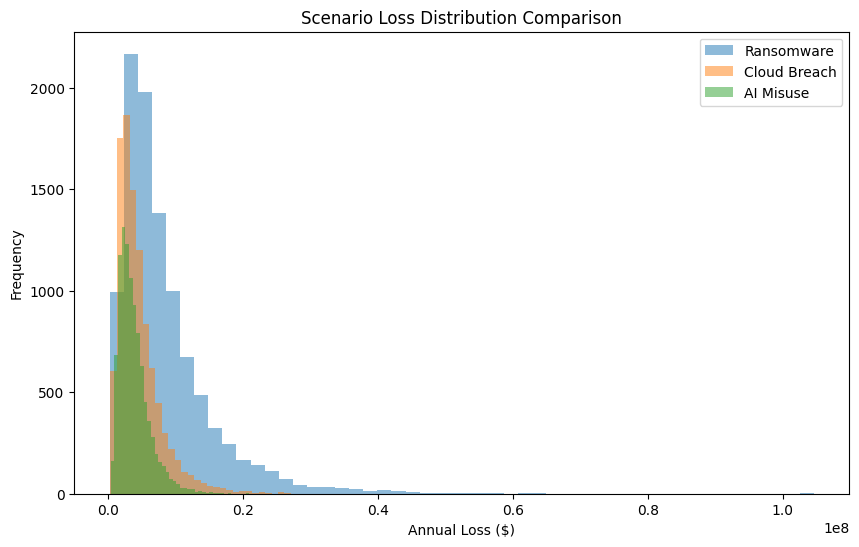

In [11]:
plt.figure(figsize=(10,6))

for scenario, ale in results.items():
    plt.hist(ale, bins=50, alpha=0.5, label=scenario)

plt.legend()
plt.title("Scenario Loss Distribution Comparison")
plt.xlabel("Annual Loss ($)")
plt.ylabel("Frequency")
plt.show()

In [12]:
# Simulate control reducing ransomware frequency by 40%

control_results = {}

for scenario, params in scenarios.items():
    tef_params = list(params["tef"])
    
    if scenario == "Ransomware":
        # reduce frequency (apply control)
        tef_params = [x * 0.6 for x in tef_params]
    
    tef = np.random.triangular(*tef_params, size=10000)
    loss = np.random.lognormal(mean=params["mean"], sigma=params["sigma"], size=10000)
    
    ale = tef * loss
    control_results[scenario] = ale

In [13]:
comparison = {}

for scenario in results.keys():
    baseline = results[scenario]
    controlled = control_results[scenario]
    
    comparison[scenario] = {
        "Baseline Median": np.percentile(baseline, 50),
        "Controlled Median": np.percentile(controlled, 50),
        "Reduction ($)": np.percentile(baseline, 50) - np.percentile(controlled, 50)
    }

pd.DataFrame(comparison)

,Ransomware,Cloud Breach,AI Misuse
Baseline Median,6.304052e+06,3.648975e+06,3.313743e+06
Controlled Median,3.794504e+06,3.694743e+06,3.275127e+06
Reduction ($),2.509547e+06,-4.576860e+04,3.861610e+04


In [14]:
ransomware_baseline = np.percentile(results["Ransomware"], 50)
ransomware_controlled = np.percentile(control_results["Ransomware"], 50)

risk_reduction = ransomware_baseline - ransomware_controlled

print(f"Estimated annual risk reduction: ${risk_reduction:,.0f}")

Estimated annual risk reduction: $2,509,547


In [15]:
control_cost = 1_000_000  # example: $1M investment

roi = (risk_reduction - control_cost) / control_cost

print(f"Estimated ROI: {roi:.2f}")

Estimated ROI: 1.51


## Control Effectiveness Insight

- Ransomware is the dominant tail-risk scenario
- Reducing frequency materially lowers expected loss
- Estimated annual risk reduction: $X
- Control investment ROI: Y%

Implication:
Security investments should be prioritized based on **financial risk reduction**, not just compliance requirements.

## Key Insights

- Ransomware shows higher frequency-driven risk
- Cloud breaches show heavier tail risk (larger extreme losses)
- AI misuse has higher frequency but lower per-event severity

Implication:
Different cyber risks require different control strategies and investment priorities.